# Laboratorio 4

In [1]:

import rasterio
import numpy as np
import matplotlib.pyplot as plt
from datetime import date
import openeo

### Ejercicio 1 

Establezca una conexión con la api de sentinel 2, puede usar para eso el módulo openeo.


In [2]:
connection = openeo.connect("https://openeo.dataspace.copernicus.eu").authenticate_oidc()

Authenticated using refresh token.


### Ejercicio 2

Descarga los .tif de cada uno de los lagos usando para eso las coordenadas o el geojson provisto


In [3]:
import json

with open("./archive/Lago_Amatitlan.geojson", "r", encoding="utf-8") as archivo:
    amatitlan = json.load(archivo)

with open("./archive/Lago_Atitlan.geojson", "r", encoding="utf-8") as archivo:
    atitlan = json.load(archivo)


print("Amatitlan, ", amatitlan)
print("Atitlan, ", atitlan)

Amatitlan,  {'type': 'FeatureCollection', 'name': 'Lago_Amatitlan', 'crs': {'type': 'name', 'properties': {'name': 'urn:ogc:def:crs:OGC:1.3:CRS84'}}, 'features': [{'type': 'Feature', 'properties': {'name': 'Lago Amatitlán'}, 'geometry': {'type': 'Polygon', 'coordinates': [[[-90.512924, 14.412347], [-90.512924, 14.493799], [-90.638065, 14.493799], [-90.638065, 14.412347], [-90.512924, 14.412347]]]}}]}
Atitlan,  {'type': 'FeatureCollection', 'name': 'Lago_Atitlan', 'crs': {'type': 'name', 'properties': {'name': 'urn:ogc:def:crs:OGC:1.3:CRS84'}}, 'features': [{'type': 'Feature', 'properties': {'name': 'Lago Atitlán'}, 'geometry': {'type': 'Polygon', 'coordinates': [[[-91.07151, 14.5948], [-91.07151, 14.750979], [-91.326256, 14.750979], [-91.326256, 14.5948], [-91.07151, 14.5948]]]}}]}


In [4]:
geometry_atl = atitlan["features"][0]["geometry"]["coordinates"][0]

longitudes_atl = [punto[0] for punto in geometry_atl]
latitudes_atl = [punto[1] for punto in geometry_atl]

crd_atl = {
  "west": min(longitudes_atl),
    "east": max(longitudes_atl),
    "south": min(latitudes_atl),
    "north": max(latitudes_atl)
}

  

Cargando los datos en cubes

In [5]:

atitlan_cube = connection.load_collection(
    "SENTINEL2_L2A",
    spatial_extent=crd_atl,
    temporal_extent=["2025-01-01", "2025-08-01"],
    bands=["B02","B03","B04", "B08"]
)

In [ ]:
# Carga todo el rango
atitlan_cube = connection.load_collection(
    "SENTINEL2_L2A",
    spatial_extent=crd_atl,
    temporal_extent=["2025-03-01", "2025-08-31"],
    bands=["B02","B03","B04","B08"]
)

# Luego filtras para quedarte con 2 imágenes por mes:
def select_two_per_month(cube):
    selected = []
    times = cube.time.to_index()  # o la forma que tenga para fechas
    for month in range(3, 9):
        month_dates = [t for t in times if t.month == month]
        # Escoge 2 fechas arbitrarias, por ejemplo las primeras 2 disponibles
        selected_dates = month_dates[:2]
        selected.extend(selected_dates)
    # Filtra el cube con estas fechas
    return cube.sel(time=selected)
print(atitlan_cube.dims)
print(atitlan_cube.coords)

atitlan_cube_filtered = select_two_per_month(atitlan_cube)


AttributeError: 'DataCube' object has no attribute 'dims'

In [ ]:
result_graph = atitlan_cube_filtered.save_result(format="GTIFF")
job = connection.create_job(result_graph)

# Iniciar y esperar que termine
job.start_and_wait()

# Obtener resultados y descargarlos a carpeta
results = job.get_results()
results.download_files("./data/GIS/")

print("Descarga finalizada.")

# Verificar archivos descargados
import os

folder = "./data/GIS/"
files = os.listdir(folder)
for f in files:
    size = os.path.getsize(os.path.join(folder, f))
    print(f"{f} - {size} bytes")

# Imprimir logs del job por si hubo errores
print("\nLogs del job:")
print(job.get_log())


0:00:00 Job 'j-2508072241104717b7906a97362ba7f9': send 'start'
0:00:13 Job 'j-2508072241104717b7906a97362ba7f9': created (progress 0%)
0:00:18 Job 'j-2508072241104717b7906a97362ba7f9': created (progress 0%)
0:00:24 Job 'j-2508072241104717b7906a97362ba7f9': created (progress 0%)
0:00:32 Job 'j-2508072241104717b7906a97362ba7f9': created (progress 0%)
0:00:43 Job 'j-2508072241104717b7906a97362ba7f9': created (progress 0%)
0:00:55 Job 'j-2508072241104717b7906a97362ba7f9': created (progress 0%)
0:01:11 Job 'j-2508072241104717b7906a97362ba7f9': running (progress N/A)
0:01:30 Job 'j-2508072241104717b7906a97362ba7f9': running (progress N/A)
0:01:54 Job 'j-2508072241104717b7906a97362ba7f9': running (progress N/A)
0:02:24 Job 'j-2508072241104717b7906a97362ba7f9': running (progress N/A)
0:03:02 Job 'j-2508072241104717b7906a97362ba7f9': running (progress N/A)
0:03:48 Job 'j-2508072241104717b7906a97362ba7f9': running (progress N/A)
0:04:47 Job 'j-2508072241104717b7906a97362ba7f9': running (progress

KeyboardInterrupt: 

In [ ]:
import os
import re
from pathlib import Path
import numpy as np
import rasterio

# Fechas válidas
clear_dates = {
    "2025-02-07","2025-02-10","2025-02-25","2025-02-27",
    "2025-03-02","2025-03-04","2025-03-07","2025-03-09",
    "2025-03-12","2025-03-14","2025-03-19","2025-03-22",
    "2025-03-24","2025-03-26","2025-04-03","2025-04-11",
    "2025-04-13","2025-04-15","2025-04-16","2025-04-18",
    "2025-04-28","2025-05-03","2025-05-13","2025-05-28",
    "2025-07-10","2025-07-17","2025-07-20","2025-07-24",
    "2025-08-01"
}

def parse_date_from_name(name):
    m = re.search(r"openEO_(\d{4}-\d{2}-\d{2})Z", name)
    return m.group(1) if m else None

def compute_index(num, den):
    with np.errstate(divide="ignore", invalid="ignore"):
        return np.where(den == 0, np.nan, num / den)

def normalize_if_needed(x):
    x = x.astype(np.float32)
    return x / 10000.0 if np.nanmax(x) > 2 else x

def _try_find_band_index_by_description(src, candidates=("B05", "705")):
    """
    Intenta ubicar el índice (1-based) de B05 buscando en descriptions o tags.
    Devuelve None si no encuentra.
    """
    # descriptions suele tener nombre tipo "B04", "B05", etc.
    if src.descriptions and any(src.descriptions):
        for i, desc in enumerate(src.descriptions, start=1):
            if not desc:
                continue
            d = desc.upper()
            if any(c in d for c in (c.upper() for c in candidates)):
                return i
    # fallback: buscar en tags por banda
    for i in range(1, src.count + 1):
        tags = src.tags(i)
        for v in tags.values():
            d = str(v).upper()
            if any(c in d for c in (c.upper() for c in candidates)):
                return i
    return None

def process_all_images(DATA_DIR, band_map=None):
    """
    Recorre todos los .tif en DATA_DIR y devuelve tres diccionarios:
    ndvi_data, ndwi_data, ndci_data (este último puede tener None si no hay B05).

    band_map (opcional) permite forzar el índice 1-based de cada banda:
        {"GREEN":1, "RED":2, "NIR":3, "SWIR":4, "B05":3}
    Ajusta según el orden real de tu stack.
    """
    ndvi_data, ndwi_data, ndci_data = {}, {}, {}

    for tif_path in Path(DATA_DIR).glob("openEO_*Z*.tif"):
        date = parse_date_from_name(tif_path.name)
        if not date or date not in clear_dates:
            continue

        with rasterio.open(tif_path) as src:
            # Detectar bandas
            if band_map is None:
                # Suponemos tu orden original:
                # 1=GREEN(B03), 2=RED(B04), 3=NIR(B08), 4=SWIR(B11)
                idx_green = 1
                idx_red   = 2
                idx_nir   = 3
                idx_swir  = 4
                # Intentar encontrar B05 por descripción (si existe en el stack)
                idx_b05 = _try_find_band_index_by_description(src, candidates=("B05", "705"))
            else:
                idx_green = band_map.get("GREEN")
                idx_red   = band_map.get("RED")
                idx_nir   = band_map.get("NIR")
                idx_swir  = band_map.get("SWIR")
                idx_b05   = band_map.get("B05") 

            green = normalize_if_needed(src.read(idx_green))
            red   = normalize_if_needed(src.read(idx_red))
            nir   = normalize_if_needed(src.read(idx_nir))

            # Índices
            ndvi = compute_index(nir - red,   nir + red)      # NDVI
            ndwi = compute_index(green - nir, green + nir)    # NDWI (McFeeters)

            # NDCI (si hallamos B05)
            ndci = None
            if idx_b05 is not None:
                b05 = normalize_if_needed(src.read(idx_b05))
                ndci = compute_index(b05 - red, b05 + red)
            else:
                # Si quieres que sea obligatorio, cambia a raise
                print(f"[AVISO] {tif_path.name}: no se encontró B05 → NDCI omitido.")

            ndvi_data[date] = ndvi
            ndwi_data[date] = ndwi
            ndci_data[date] = ndci  # puede ser None

    return ndvi_data, ndwi_data, ndci_data

# --- Usa la función para ambos lagos ---
DATA_DIR = "./Atitlan/Atitlan"
AMA_DIR  = "./Amatitlan/Amatitlan"

atitlan_ndvi, atitlan_ndwi, atitlan_ndci = process_all_images(DATA_DIR)
amatitlan_ndvi, amatitlan_ndwi, amatitlan_ndci = process_all_images(AMA_DIR)

print("Atitlán:", len(atitlan_ndvi), "fechas NDVI,", sum(v is not None for v in atitlan_ndci.values()), "con NDCI")
print("Amatitlán:", len(amatitlan_ndvi), "fechas NDVI,", sum(v is not None for v in amatitlan_ndci.values()), "con NDCI")





Atitlán: 28 fechas NDVI, 28 con NDCI
Amatitlán: 18 fechas NDVI, 18 con NDCI


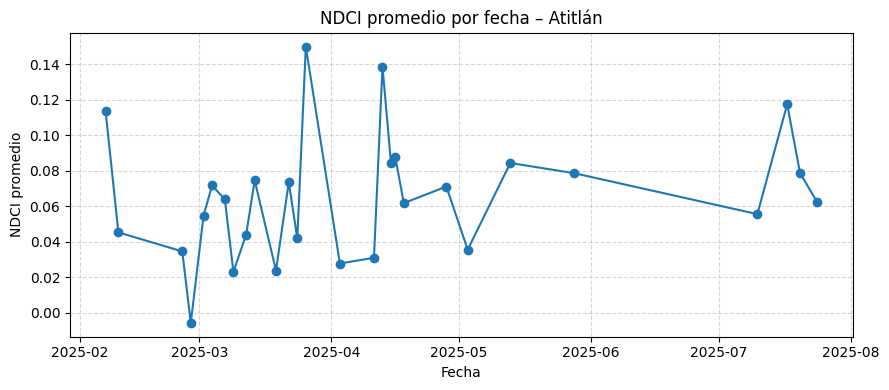

Listo: ndci_mean_timeseries.csv y ndci_mean_timeseries.png generados.


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def series_y_grafico(index_dict, titulo, y_label, csv_out, png_out, clip_min=-1.0, clip_max=1.0):
    """
    index_dict: dict { 'YYYY-MM-DD': ndarray2D | None }
    titulo:     str  título del gráfico
    y_label:    str  etiqueta del eje Y
    csv_out:    str  ruta del CSV a guardar
    png_out:    str  ruta del PNG a guardar
    clip_min/max:    límites para recortar valores extremos antes de promediar
    """
    rows = []
    for d, arr in index_dict.items():
        if arr is None:
            # p. ej., NDCI ausente si no hubo B05 para esa fecha
            continue
        arr_clip = np.clip(arr.astype(np.float32), clip_min, clip_max)
        rows.append({"date": pd.to_datetime(d), "mean": np.nanmean(arr_clip)})

    if not rows:
        raise ValueError("No hay datos válidos para construir la serie.")

    df = (pd.DataFrame(rows)
            .sort_values("date")
            .set_index("date"))

    # Guardar CSV
    df.to_csv(csv_out)

    # Graficar
    plt.figure(figsize=(9,4))
    plt.plot(df.index, df["mean"], marker="o")
    plt.title(titulo)
    plt.xlabel("Fecha")
    plt.ylabel(y_label)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.savefig(png_out, dpi=150)
    plt.show()

    print(f"Listo: {csv_out} y {png_out} generados.")
    return df  # por si quieres reutilizar la serie en más análisis


ndci_df = series_y_grafico(
    atitlan_ndci,
    "NDCI promedio por fecha – Atitlán",
    "NDCI promedio",
    "ndci_mean_timeseries.csv",
    "ndci_mean_timeseries.png",
    clip_min=-0.5, clip_max=0.8  # ejemplo
)


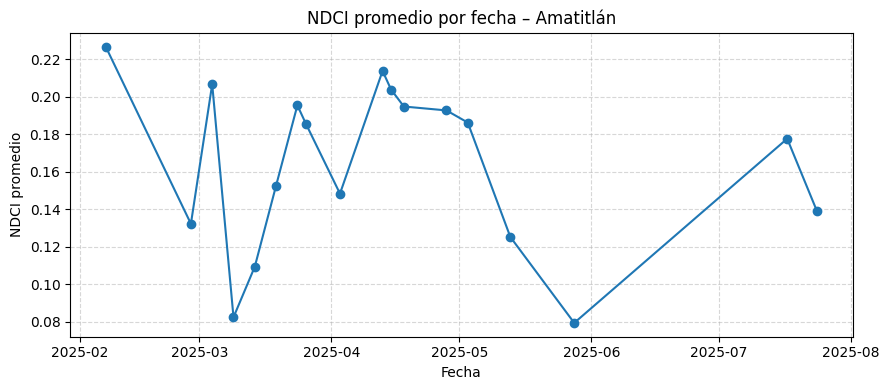

Listo: ndci_mean_timeseries_amatitlan.csv y ndci_mean_timeseries_amatitlan.png generados.


In [15]:
ndci_df2 = series_y_grafico(
    amatitlan_ndci,
    "NDCI promedio por fecha – Amatitlán",
    "NDCI promedio",
    "ndci_mean_timeseries_amatitlan.csv",
    "ndci_mean_timeseries_amatitlan.png",
    clip_min=-0.5, clip_max=0.8  # ejemplo
)